# 3D 복부 및 흉부 self-supervised 세그멘테이션 모델 개발

프로젝트 번호: 1

---
`소스코드 참고 사항`
- RAM 부족한 경우: input_shape=(128, 128, 3)를 input_shape=(64, 64, 3)로 변경
- GPU 학습이 안 되는 경우: batch_size를 16으로 변경
---

# 목차

1. 프로젝트 개요
    1. 프로젝트 연구 배경
    1. Swin Transformer와 Swin UNETR 모델
    1. Swin UNETR 모델의 적용 및 기대 효과
1. 실습 환경 설정
	1. 엘리스 클라우드 가입
	1. 인스턴스 생성
	1. 인스턴스 삭제
    1. 인스턴스 SSH 접속
    1. 버전 확인
	1. 코드 업로드
    1. 패키지 설치
1. 데이터셋 준비
    1. 데이터셋 소개 
    1. 데이터셋 다운로드
    1. 데이터셋 업로드
1. 실제 모델 구축을 위한 실습(셀 단위 실습)
    1. 셀 1: 필요한 패키지 설치
    1. 셀 2: 주요 라이브러리 임포트 및 환경 출력
    1. 셀 3: 데이터 저장 경로 설정
    1. ...
    1. 셀 22: 모델 파일 복사
1. 결론
	1. 주요 업적
	1. 기존 연구와의 차별점
	1. 기술적 한계 및 향후 연구 과제


# 프로젝트 개요

예상 모델 학습 소요시간: `80분`\
컴퓨팅 성능 요구: `높음`\
논문: 
Tang, Yucheng, et al. "Self-supervised pre-training of swin transformers for 3d medical image analysis." Proceedings of the IEEE/CVF conference on computer vision and pattern recognition. 2022.\
소스코드 원본 주소: https://github.com/Project-MONAI/research-contributions/tree/main/SwinUNETR/BTCV



## 프로젝트 연구 배경

- **의료 영상 분석의 중요성:** 정확한 의료 영상 분석은 질병 진단과 치료 계획 수립에 필수적이며, 특히 복부 CT 스캔에서 여러 장기의 정확한 분할은 다양한 임상 적용에 중요
- **전통적인 CNN 기반 모델의 한계:** 기존의 합성곱 신경망(CNN) 기반 모델은 지역적 특징을 잘 포착하지만 장거리 의존성을 학습하는 데 제한이 있으며, 이는 복잡한 해부학적 구조를 가진 의료 영상에서 정확한 분할을 어렵게 만듦
- **Transformer 모델의 도입:** 자연어 처리 및 컴퓨터 비전 분야에서 Transformer 모델은 전역적인 특징 학습에 뛰어난 성능을 보여주며, 이러한 특성을 의료 영상 분석에 적용하여 성능 향상을 기대할 수 있음
- **Swin Transformer의 특징:** Swin Transformer는 윈도우 기반의 self-attention 메커니즘을 활용하여 계산 효율성을 높이면서도 전역적 정보를 효과적으로 학습할 수 있음
- **Swin UNETR 모델의 개발:** Swin UNETR은 Swin Transformer를 인코더로 사용하고, CNN 기반 디코더와 결합하여 다중 장기 분할 작업에서 우수한 성능을 달성한 모델 

`기술 동향`
- Transformer 기반 모델의 도입과 확장: 자연어 처리 분야에서 성공을 거둔 Transformer 구조가 의료 영상 분석 분야로 확장 적용되고 있음
    - Wang et al. (2021): TransBTS 모델을 통해 brain tumor segmentation 수행 (TransBTS 논문에서 언급)
    - Hatamizadeh et al. (2022): UNETR 모델에서 ViT 기반 encoder와 CNN decoder를 연결하여 3D segmentation 수행

- Swin Transformer의 활용 확대: Swin Transformer는 Shifted Window 기반 self-attention을 도입하여 계산 효율성과 성능을 모두 확보함
    - Liu et al. (2021): 일반 비전 문제에서 Swin Transformer 제안, hierarchical 구조 도입 (Swin Transformer 원 논문)

- 3D 의료 영상에 특화된 구조의 필요성: 기존 2D CNN 또는 Transformer 모델은 volumetric 정보의 손실로 한계가 존재
    - Chen et al. (2021): TransUNet에서 2D CNN과 Transformer 결합
    - Tang et al. (2022): UNETR는 3D patch 단위 입력과 계층 구조로 3D 영상에 최적화

## Swin Transformer와 Swin UNETR

`Swin Transformer`
- 기존 Vision Transformer는 연산량이 많고 고해상도 영상 처리에 비효율적이라는 한계가 있었음
- Swin Transformer는 윈도우 단위(local window)로 self-attention을 수행해 계산 효율을 크게 향상시킴
- Shifted Window 방식을 통해 지역적 정보뿐 아니라 전역적인 정보도 점진적으로 학습 가능
* 계층적 구조(Hierarchical Structure)를 통해 다양한 해상도 수준의 feature를 효과적으로 추출
* 일반적인 Vision Task뿐 아니라, 의료 영상 segmentation과 같은 정밀한 분석 분야에도 확장 가능함

<figure>
    <img src="https://kimjy99.github.io/assets/img/swin-transformer/swin-transformer-fig1.webp" width="800"/>
    <figcaption>그림 1: Swin Transformer의 계층적 구조와 기존 ViT 구조와의 차이<br>https://kimjy99.github.io/%EB%85%BC%EB%AC%B8%EB%A6%AC%EB%B7%B0/swin-transformer/</figcaption>
</figure>


`Swin UNETR`
- Swin UNETR은 Swin Transformer 인코더 + CNN 디코더 구조를 사용하는 3D 의료 영상 세분화(Segmentation) 모델임
- 입력은 3D CT 이미지이며, Patch Partition을 통해 작은 패치로 분할하여 transformer 인코더에 입력됨
- 인코더는 Swin Transformer 기반으로 구성되며, shifted window self-attention을 통해 장거리 의존성을 효과적으로 학습함
* Swin Transformer 인코더는 총 4단계로 구성되며, 각 단계마다 패치 해상도를 줄여가며 계층적 특징을 추출함
* 디코더는 CNN 기반 U-Net 형태로 구성되어 있으며, skip connection을 통해 인코더의 feature를 각 해상도 단계에서 받아 병합함
* 최종적으로 segmentation mask를 출력함

* 본 모델은 BTCV 및 MSD challenge에서 우수한 성능을 보였으며, annotation이 적은 조건에서도 효율적인 학습 가능성을 입증함


<figure>
    <img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*H0RK09ErZ5vx_jxIkhpx-w.png" width="1000"/>
    <figcaption>그림 2: Swin UNETR 아키텍처<br>https://arxiv.org/pdf/2111.14791</figcaption>
</figure>

## Swin Transformer 기반 Swin UNETR 적용의 기대 효과

`Swin Transformer 기반 Swin UNETR 적용의 기대 효과(1/3)`
- Swin Transformer의 구조적 강점 기반 feature 학습
    - Shifted window self-attention을 통해 계산 효율성과 성능을 동시에 확보
	- 기존 ViT 대비 연산량을 줄이며 3D patch 기반 입력을 효율적으로 처리

- Patch 기반 입력 분할로 장기 간 경계 인식 향상
    - 복잡한 해부학적 구조에서도 정확한 경계 인식 가능
	- Patch Merging을 통한 multi-scale feature 추출

`Swin Transformer 기반 Swin UNETR 적용의 기대 효과(2/3)`
- Self-supervised pre-training 기반 학습을 통한 annotation 비용 절감
    - unlabeled 3D CT 데이터 5,050개로 사전 학습하여 라벨이 적은 상황에서도 높은 성능 확보
	- 전체 라벨의 60%만 사용해도 full-label training과 유사한 성능 확보 가능 (BTCV 기준, Fig. 7 참조)
- 복잡한 3D 해부학 구조에 대한 정밀한 분할 성능
    - 여러 장기의 위치·형태가 혼재된 복부 CT에서 소형 장기(췌장, 정맥, 부신 등)까지 우수한 분할 성능 확인
    - BTCV challenge에서 평균 Dice 0.918 기록하며 기존 모델보다 성능 우위 입증

- Swin 구조의 계층적 특성으로 multi-scale feature 학습 가능
    - 4단계 encoder를 통해 서로 다른 해상도의 특징을 추출하고, CNN 디코더에서 통합하여 정밀 분할 수행
    - 작은 병변이나 구조도 놓치지 않고 반영 가능


`Swin Transformer 기반 Swin UNETR 적용의 기대 효과(3/3)`
- 다양한 의료 영상 분석 task로의 확장 가능성
    - classification, detection 등 다른 task에도 transfer learning 가능성 언급 (논문 Discussion 참조)
	- Swin UNETR encoder는 다양한 downstream task에서 재사용 가능
- 추론 속도 및 모델 효율성 측면에서 실용성 확보
    - 현재는 CT 기반이나, MRI 등 다른 modality로의 확장도 연구 가능
	- rotation, inpainting 외의 새로운 self-supervised task 추가 가능성 있음

# 실습 환경 설정

## 엘리스 클라우드 가입

1. 엘리스 클라우드 가입 시 사용할 이메일 주소로 초대장이 보내짐
1. 이메일을 열어 초대장 메일을 확인

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/mail1.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. "`학습지 가기`"를 클릭하여 로그인 화면으로 이동

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/mail2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. 메일에 나와있는 이메일 아이디와 임시포스트를 입력하여 로그인

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/login.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. 사용할 비밀번호를 입력하고 필수 동의사항에 동의 후 회원가입 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/login2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

6. 회원가입 완료

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/login3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 인스턴스 생성

1. 왼쪽 상단의 LXP를 클락한 뒤 클라우드를 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/cloud.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 내 인스턴스 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/cloud2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. 인스턴스 생성을 클릭하여 생성 화면으로 이동

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/cloud3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. 인스턴스 유형으로 G-NAHP-80(A100 80GB PCle)을 선택

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/instance.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. 인스턴스 이름 작성 후 실행 환경은 Jupyter 선택

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/instance2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

6. 스토리지 옵션으로 `{프로젝트 용량 고려}`GB 선택\
주의: 본 프로젝트의 용량이 `{프로젝트 용량}`GB이므로 프로젝트 용량보다 더 큰 용량 선택
7. 이후 인스턴스 생성을 클릭해 생성을 완료

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/instance3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

8. 이제 생성된 인스턴스에서 실습을 진행함
1. 이후 내 인스턴스 페이지로 돌아가기 위해 왼쪽 상단의 내 인스턴스 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/instance4.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 인스턴스 삭제

- 인스턴스 화면에 없어도 인스턴스는 계속 실행되고 있으므로 삭제 필요
- 사용이 끝난 경우 반드시 ‘종료’ 버튼을 눌러 실행을 중지해야 함\
(단, 종료는 인스턴스에 여전히 필요한 데이터나 설정이 남아 있는 경우에만 사용)
- 인스턴스를 더 이상 사용할 일이 없다면, ‘삭제’를 통해 완전히 제거해야함
- 삭제는 반드시 인스턴스가 종료된 상태에서만 가능하며, 한 번 삭제하면 복구할 수 없음

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/instance5.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 인스턴스 접속(SSH)

### PEM 다운로드

> 주의: 한번 다운로드 받은 PEM 파일은 잘 보관해야 함\
> 재 발급 받은 경우 키 값이 달라지므로 재 발급 받은 파일로는 기존의 인스턴스에 접속 불가함\
> SSH 접속은 실습 환경에 필요한 모듈을 다운받는 등에 사용함

1. SSH 접속을 위해서는 비밀키 파일(PEM 파일)이 필요\
비밀키 발급하기 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/key.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. SSH 접속을 위해서는 비밀키 파일(PEM 파일) 필요\
PEM 파일 다운로드하기를 클릭하여 PEM 파일 저장

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/key2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

### Command Prompt(혹은 Powershell) 실행

1. 윈도우(<span style="font-family: 'Wingdings';">&#xFF;</span>)  + R 키를 누르기
1. cmd 입력 (또는 powershell 입력)
1. Enter키 눌러서 Command Prompt 실행

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/key3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. "`cd [PEM파일 폴더 경로]`" 명령어를 사용하여 PEM 파일이 있는 위치로 이동\
예시: `cd %userprofile%\Downloads`\
(PEM 저장 위치 예시: 다운로드 폴더, 바탕화면, USB 등...)

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/key4.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

### SSH 접속 명령어

1. 내 인스턴스 페이지에서 다른 SSH 클라이언트 사용 선택

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/ssh.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 빠른 연결칸의 명령어를 복사

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/ssh2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 복사한 명령어를 앞서 실행한 powershell 또는 cmd에 붙여넣기

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/ssh3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. SSH 접속 완료, SSH 접속 창은 계속 사용 되므로 창을 닫지 않음

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/ssh4.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 버전 확인

### 논문에서 구성한 버전 정보

- MONAI: 1.5.dev2510 
- Numpy: 1.26.4 
- Pytorch: 2.5.1+cu124
- Nibabel: 5.3.2 
- scikit-image: 0.25.2 
- scipy: 1.13.1 
- Pillow: 11.1.0 
- Tensorboard: 2.18.0
- gdown: 5.2.0 
- TorchVision: 0.20.1+cu124
- tqdm: 4.67.1 
- psutil: 5.9.5 
- pandas: 2.2.2 
- eipnos: 0.8.1 
- transformers: 4.48.3 
- opencv-python: 4.1.2.30 

### 파이썬 버전 확인

주피터 노트북에서 아래 명령어를 입력하여 확인하며 `엘리스 클라우드`의 주피터 노트북에 접속하여 입력함
> Tip: 파이썬 버전에 따라 텐서플로우 설치 가능 버전이 달라짐

1. 내 인스턴스에서 연결을 클릭하여 Jupyter notebook에 접속

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/version.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 우측 상단 `new` 버튼 클릭후 `Python 3(ipykernel)` 버튼 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/version2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. 코드를 작성하여 파이썬 버전을 확인

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/version3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

In [ ]:
import sys

print("Python version", sys.version)

## 코드 업로드

### 주피터 노트북 웹 페이지에서 바로 업로드 하기

1. 내 인스턴스에서 연결을 클릭하여 Jupyter notebook에 접속

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/version.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 좌측 상단에 있는 `Upload` 버튼 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/upload1.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. 열기 대화창이 뜨면 다운 받은 주피터노트북 교육자료 파일(*.jpynb) 선택 후 `열기(O)` 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/upload2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. 파란색 `Upload` 버튼을 클릭하여 엘리스 클라우드 서버로 파일 업로드

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/upload3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. 업로드한 교육자료 파일을 클릭하여 파일 열기

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/upload4.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

6. 강사의 지도에 따라 교육 자료를 활용합니다.

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/upload5.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 패키지 설치

### Miniconda 설치

> 원할하게 다양한 실습환경을 구축하기 위해 Miniconda의 가상환경을 생성하여 실습을 진행

SSH접속 후 아래의 명령어를 순차적으로 실행
- wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
- bash Miniconda3-latest-Linux-x86_64.sh
- source ~/.bashrc

1. 명령어 작성 예시

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/miniconda.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. Please, press Enter to continue가 나오면 Enter 키를 누른 후 Page Down 키를 눌러 가장 아래로 내려감

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/miniconda2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. Do you accept the license terms? [yes/no]가 나오며 yes 입력 후 Enter 키를 눌러 넘어감

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/miniconda2-1.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. You can undo this by running 'conda init --reverse $SHELL'? [yes/no]가 나오면 yes를 입력하여 Miniconda 설치 완료

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/miniconda2-2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. Miniconda 설치 완료\
source ~/.bashrc 를 입력하여 변경 사항을 적용

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/miniconda3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

### Conda 가상환경 생성 및 활성화

1. SSH에 가상환경 생성 명령어 작성
- conda create -n btcv python=3.11.11
> conda create -n `가상환경 이름` python=`파이썬 버전`\

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/CondaEnv.png?raw=true" width="900">
    <figcaption>가상환경 생성 명령어 작성 예시</figcaption>
</figure>

2. 가상 환경 실행
- conda activate btcv
> conda activate `가상환경 이름`

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/CondaEnv2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

### Jupyter Notebook과 가상환경 연동

1. ipykernel 설치
- pip install ipykernel

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/CondaEnv3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. Jupyter Notebook에서 이 가상환경을 선택 가능한 커널로 등록
- python -m ipykernel install --user --name=ICELAB --display-name "Ice-Lab"
> python -m ipykernel install --user --name=`가상환경 이름` --display-name "`Jupyter에서 보여지는 이름`"

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/CondaEnv4.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. Jupyter Notebook에서 python3.8 버전으로 notebook 생성 가능

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/CondaEnv5.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. 기존에 생성된 notebook에서 커널 변경 가능

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/CondaEnv6.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. python 버전이 정상적으로 변경 되었는지 확인

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/CondaEnv7.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

In [ ]:
import sys

print("Python version", sys.version)

Python version 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 18:56:27) [GCC 11.2.0]


### CUDA 설정

1. 패키지 관리자 업데이트
- sudo apt-get update
<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/cuda1.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. CUDA Toolkit 설치
- sudo apt-get install -y cuda-toolkit-12-4

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/cuda2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. cuDNN 설치
- sudo apt-get install -y libcudnn9-cuda-12

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/cuda3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

### GPU 확인

NVIDIA 드라이버 확인

In [2]:
!nvidia-smi

Thu Apr  3 08:39:52 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.06             Driver Version: 535.183.06   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100 80GB PCIe          On  | 00000000:E3:00.0 Off |                    0 |
| N/A   32C    P0              42W / 300W |      0MiB / 81920MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

CUDA 버전 확인

In [3]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Mar_28_02:18:24_PDT_2024
Cuda compilation tools, release 12.4, V12.4.131
Build cuda_12.4.r12.4/compiler.34097967_0


cuDNN 버전 확인

In [5]:
!cat /usr/include/cudnn.h | grep CUDNN_MAJOR -A 2

Tensorflow 설치

가상 환경이 활성화된 SSH에 다음 명령어 입력
- pip install tensorflow

CUDA 지원 확인
- 정상적인 경우 GPU 갯수가 1개로 표시됩니다.
- 비정상적인 경우 GPu 갯수가 0개로 표시됩니다.

In [ ]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices("GPU")))

2025-04-03 08:40:42.986376: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-03 08:40:43.005058: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743669643.025559     288 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743669643.031661     288 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743669643.047259     288 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Num GPUs Available:  1


### 필요한 라이브러리

`요구 사항`
- MONAI: 1.5.dev2510 
- Numpy: 1.26.4 
- Pytorch: 2.5.1+cu124
- Nibabel: 5.3.2 
- scikit-image: 0.25.2 
- scipy: 1.13.1 
- Pillow: 11.1.0 
- Tensorboard: 2.18.0
- gdown: 5.2.0 
- TorchVision: 0.20.1+cu124
- tqdm: 4.67.1 
- psutil: 5.9.5 
- pandas: 2.2.2 
- eipnos: 0.8.1 
- transformers: 4.48.3 
- opencv-python: 4.1.2.30 

### 패키지 버전 및 설치 확인

`필요 라이브러리 설치 명령어`

가상환경이 활성화된 상태의 SSH에 입력<br/>
python -c "import monai; import nibabel; import tqdm" || pip install -q "monai-weekly[nibabel, tqdm]" <br/>
python -c "import matplotlib" || pip install -q matplotlib <br/>
pip install scikit-image scikit-learn gdown torchvision pandas einops transformers 

`주피터 노트북 환경에서 패키지 설치 여부 및 버전 확인`

In [ ]:
import skimage

print("skimage version", skimage.__version__)
import tensorflow as tf

print("tensorflow version", tf.__version__)

skimage version 0.25.2
tensorflow version 2.19.0


`Linux 환경에서 패키지 설치 여부 및 버전 확인`
- pip list | grep `패키지_이름`
- conda list | grep `패키지_이름`

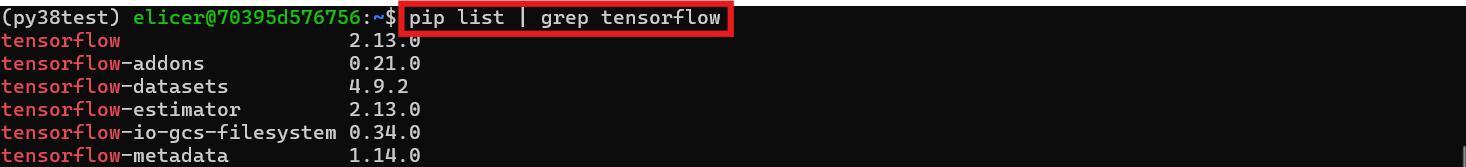\
*명령어 작성 예시*

> Tip: Windows는 grep 명령어 대신 findstr 명령어를 사용합니다.\
> %pip list | findstr `패키지_이름`\
> %conda list | findstr `패키지_이름`

---
# 데이터셋 준비

## 데이터셋 소개

논문에 쓰인 데이터셋 관련 소개
(데이터셋 셈플 시각화, 관련 정보)

`BTCV Dataset`
- 본 실습에서 실제로 사용되는 데이터셋으로 Beyond the Cranial Vault의 약자로, 복부 CT 영상 기반의 13개 복부 장기 분할 데이터셋임
- 간, 신장, 비장, 위, 방광 등 주요 장기를 포함
- 모델의 일반화 성능을 평가하기 위해 다양한 해부학적 구조가 포함됨
- 모든 영상은 CT 기반 3D Volume (NIfTI format)이며, MONAI에서 공식 지원
- Swin UNETR 모델은 BTCV 챌린지에서 높은 Dice score (0.918 평균) 달성함\
![btcv_eg.png](./image/btcv_eg.png)


## 데이터셋 다운로드

[BTCV 데이터셋 다운로드 하기](https://www.synapse.org/#!Synapse:syn3193805/wiki/217752)
<br/>링크: https://www.synapse.org/#!Synapse:syn3193805/wiki/217752

1. 먼저 Synapse에 새로 가입해야 함. 좌측 하단의 로그인 아이콘 클릭

<figure>
    <img src="https://github.com/jhlimdev/kdt_edu_img/blob/main/btcv_dataset0.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 가장 하단의 텍스트를 클릭하여 계정 생성

<figure>
    <img src="https://github.com/jhlimdev/kdt_edu_img/blob/main/btcv_dataset1.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. 구글 로그인 혹은 타 도메인 계정 사용 방법 중 각자 편한 방법을 사용

<figure>
    <img src="https://github.com/jhlimdev/kdt_edu_img/blob/main/btcv_dataset2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. 가입 후 다시 https://www.synapse.org/#!Synapse:syn3193805/wiki/217752 링크에 접속하여 Files 탭 클릭.(연한 핑크색 동그라미는 현재 로그인이 되었다는 것을 보여줌)
<figure>
    <img src="https://github.com/jhlimdev/kdt_edu_img/blob/main/btcv_dataset3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. 파일 중 가장 상단의 Abdomen 좌측의 검은색 삼각형을 클릭. 혹은 이름을 클릭해서 해당 디렉터리 내부로 진입해도 무관.

<figure>
    <img src="https://github.com/jhlimdev/kdt_edu_img/blob/main/btcv_dataset4.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

6. Download Options를 클릭 후, Download file을 클릭하여여 단일 RawData.zip 파일을 다운로드

<figure>
    <img src="https://github.com/jhlimdev/kdt_edu_img/blob/main/btcv_dataset5.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 데이터셋 업로드

1. 우측 상단의 Upload 버튼 클릭 후 파일 탐색기의 다운로드 받은 RawData.zip 파일을 클릭

<figure>
    <img src="https://github.com/jhlimdev/kdt_edu_img/blob/main/btcv_dataset6.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 파란색의 Ok 버튼을 클릭

<figure>
    <img src="https://github.com/jhlimdev/kdt_edu_img/blob/main/btcv_dataset7.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. Upload 버튼을 다시 클릭하여 즉시 업로드 작업 수행

<figure>
    <img src="https://github.com/jhlimdev/kdt_edu_img/blob/main/btcv_dataset8.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. 업로드가 진행되고 있는 화면. 업로드가 완료될때까지 디렉터리를 이동하는 등 다른 작업 삼가.(업로드가 즉시 중단되며, 일부분만 올라간 불완전한 데이터셋이 업로드 됨)

<figure>
    <img src="https://github.com/jhlimdev/kdt_edu_img/blob/main/btcv_dataset9.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

# 실제 모델 구축을 위한 실습

## 셀1: 필요한 패키지 설치
- 주요 라이브러리 설치를 위한 셀
- MONAI, nibabel, tqdm, matplotlib 등 Swin UNETR 및 의료 영상 처리에 필요한 패키지를 설치
- transformers는 Swin Transformer 관련 백본 모델 활용을 위한 라이브러리

In [ ]:
# [MONAI, nibabel, tqdm]이 이미 설치되어 있는지 확인하고, 설치 안 되어 있으면 설치함
# - monai: 의료 영상 처리를 위한 PyTorch 기반 프레임워크
# - nibabel: .nii, .nii.gz 같은 의료 영상 포맷을 다루기 위한 라이브러리
# - tqdm: 진행률(progress bar) 표시를 위한 라이브러리
!python -c "import monai; import nibabel; import tqdm" || pip install -q "monai-weekly[nibabel, tqdm]"

# matplotlib이 설치되어 있는지 확인하고, 설치 안 되어 있으면 설치함
# - matplotlib: 데이터 시각화를 위한 가장 기본적인 파이썬 라이브러리
!python -c "import matplotlib" || pip install -q matplotlib

# Swin UNETR 학습에 필요한 기타 필수 라이브러리 설치
!pip install scikit-image scikit-learn gdown torchvision pandas einops transformers

# 설명:
# - scikit-image: 이미지 처리 유틸리티 (예: 필터링, 마스크 등)
# - scikit-learn: 머신러닝 도구 (데이터셋 분할, 평가 등)
# - gdown: 구글 드라이브에서 파일을 쉽게 다운로드
# - torchvision: PyTorch에서 이미지 데이터 처리에 사용하는 모듈
# - pandas: 데이터프레임 처리 (CSV 읽기 등)
# - einops: Tensor 재배열 (reshape, reduce, repeat 등 편리하게)
# - transformers: Swin Transformer 사전 학습 모델을 불러올 때 사용

## 셀2: 주요 라이브러리 임포트 및 환경 출력
- 학습에 필요한 MONAI, PyTorch, 기타 유틸리티 라이브러리를 import
- print_config()를 통해 MONAI 환경 설정 정보를 출력 (버전, 디바이스 상태 등 확인용)

In [ ]:
# 🔧 기본 라이브러리
import os  # 파일 경로/이름 설정 및 디렉토리 작업용
import shutil  # 파일 및 폴더 복사/이동/삭제 등 유틸리티
import tempfile  # 임시 디렉토리 생성을 위한 모듈

# 📊 시각화 및 진행률 표시용
import matplotlib.pyplot as plt  # 이미지나 그래프 시각화를 위한 라이브러리
from tqdm import tqdm  # 반복문의 진행 상황을 보여주는 진행률 표시바

# 🧠 MONAI 관련 모듈 (의료 영상 AI를 위한 PyTorch 기반 라이브러리)
from monai.losses import (
    DiceCELoss,
)  # Dice + CrossEntropy 복합 손실 함수 (Segmentation에 특화)
from monai.inferers import (
    sliding_window_inference,
)  # 큰 3D 볼륨을 작은 슬라이딩 윈도우로 나눠 추론할 때 사용
from monai.transforms import (  # 데이터 전처리 및 augmentation에 사용하는 다양한 변환들
    AsDiscrete,  # 모델 출력 결과를 이산형(one-hot 등)으로 변환
    Compose,  # 여러 변환을 순차적으로 묶는 파이프라인
    CropForegroundd,  # 관심 영역(FG)만 잘라내는 전처리
    LoadImaged,  # 이미지(.nii.gz 등) 파일을 메모리로 불러옴
    Orientationd,  # 의료 영상의 공간 방향을 표준화
    RandFlipd,
    RandRotate90d,  # 데이터 증강: 무작위 플립/회전
    RandCropByPosNegLabeld,  # 양성/음성 위치 기반 무작위 크롭 (불균형 데이터 보정)
    RandShiftIntensityd,  # 밝기 무작위 이동 (CT/ MRI의 contrast 다양화)
    ScaleIntensityRanged,  # 픽셀 값 정규화 (일정 범위로 스케일링)
    Spacingd,  # 픽셀 간 간격(Spacing)을 표준화
    EnsureTyped,  # 데이터 타입 보정 (Tensor로 변환 등)
)

from monai.config import print_config  # MONAI, PyTorch, CUDA 등 환경 정보 출력용
from monai.metrics import DiceMetric  # Segmentation 모델 평가 지표 (Dice Score)
from monai.networks.nets import SwinUNETR  # 논문에서 사용하는 Swin UNETR 모델 클래스

# 🗂️ 데이터셋 처리 관련 모듈
from monai.data import (
    ThreadDataLoader,  # PyTorch DataLoader의 병렬 처리 버전
    CacheDataset,  # 데이터셋을 메모리에 캐싱하여 빠른 접근 가능
    load_decathlon_datalist,  # JSON 포맷의 의료 영상 목록 로더
    decollate_batch,  # 배치 데이터를 개별 샘플로 나누는 유틸리티
    set_track_meta,  # 메타데이터 추적 여부 설정
)

# ⚙️ PyTorch 기본 모듈 (GPU 사용 및 텐서 연산)
import torch

# 💡 현재 설치된 MONAI, PyTorch, 기타 설정 정보 출력
print_config()

## 셀3: 데이터 저장 경로 설정
- 데이터가 저장될 경로를 설정하는 셀
- 환경 변수 MONAI_DATA_DIRECTORY가 있으면 해당 경로를, 없으면 tempfile을 통해 임시 디렉토리를 생성

In [ ]:
# 환경 변수 'MONAI_DATA_DIRECTORY'가 설정되어 있는지 확인
# 이 환경변수가 있다면 그 위치에 데이터를 저장하고, 없다면 임시 폴더를 생성함
directory = os.environ.get("MONAI_DATA_DIRECTORY")

# 만약 MONAI_DATA_DIRECTORY가 설정되어 있다면 해당 디렉토리를 생성 (이미 존재하면 무시)
if directory is not None:
    os.makedirs(directory, exist_ok=True)

# 최종 데이터 저장 경로 결정
# - 환경변수로 지정된 경로가 있으면 그대로 사용
# - 없으면 tempfile을 이용해 임시 디렉토리를 생성
root_dir = tempfile.mkdtemp() if directory is None else directory

# 최종 저장 경로 출력
print(root_dir)

## 셀4: 데이터 전처리 및 augmentation 정의
- 학습용과 검증용 데이터에 대해 각각의 변환 파이프라인 정의
- CropForeground, Orientation, Spacing, RandFlip, RandRotate90, RandShiftIntensity 등
MONAI에서 제공하는 3D 데이터 전처리 및 augmentation 기법들을 적용
- ScaleIntensityRanged: CT의 HU 값을 0~1 사이로 정규화

In [ ]:
# 학습 시 사용될 무작위 샘플 수 설정 (Crop 시 사용됨)
num_samples = 4

# CUDA 디바이스 설정 (Colab이나 여러 GPU 환경에서 디바이스 순서 보장)
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_transforms = Compose(
    [
        # "image"와 "label" 키에 해당하는 데이터를 불러오고, 채널 차원을 추가함
        LoadImaged(keys=["image", "label"], ensure_channel_first=True),
        # CT 이미지의 HU 값을 -175 ~ 250 범위로 잘라낸 후, 0~1 사이로 정규화
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-175,
            a_max=250,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        # 이미지에서 foreground(장기)가 있는 부분만 잘라냄
        CropForegroundd(keys=["image", "label"], source_key="image"),
        # 의료 영상의 방향(Axis code)을 RAS(Right-Anterior-Superior) 표준으로 맞춤
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        # 픽셀 간 거리(spacing)를 표준화함 → 모든 데이터 해상도 통일
        Spacingd(
            keys=["image", "label"],
            pixdim=(1.5, 1.5, 2.0),  # 실제 거리 기준 (mm)
            mode=("bilinear", "nearest"),  # image는 bilinear, label은 nearest로 보간
        ),
        # 데이터를 GPU로 옮기고, 텐서로 변환함
        EnsureTyped(keys=["image", "label"], device=device, track_meta=False),
        # 랜덤 크롭 (장기 포함된 위치/아닌 위치를 모두 샘플링)
        RandCropByPosNegLabeld(
            keys=["image", "label"],
            label_key="label",
            spatial_size=(96, 96, 96),
            pos=1,
            neg=1,
            num_samples=num_samples,
            image_key="image",
            image_threshold=0,
        ),
        # 데이터 증강: 3축 각각에 대해 무작위로 좌우반전 (10% 확률)
        RandFlipd(keys=["image", "label"], spatial_axis=[0], prob=0.10),
        RandFlipd(keys=["image", "label"], spatial_axis=[1], prob=0.10),
        RandFlipd(keys=["image", "label"], spatial_axis=[2], prob=0.10),
        # 무작위 90도 회전 (최대 3회까지) → orientation 다양화
        RandRotate90d(keys=["image", "label"], prob=0.10, max_k=3),
        # 밝기 이동 (intensity shift): 50% 확률로 값 변경
        RandShiftIntensityd(keys=["image"], offsets=0.10, prob=0.50),
    ]
)

val_transforms = Compose(
    [
        # 이미지/라벨 불러오기 (채널 추가 포함)
        LoadImaged(keys=["image", "label"], ensure_channel_first=True),
        # HU 정규화 (학습과 동일)
        ScaleIntensityRanged(
            keys=["image"], a_min=-175, a_max=250, b_min=0.0, b_max=1.0, clip=True
        ),
        # foreground 기준으로 잘라내기
        CropForegroundd(keys=["image", "label"], source_key="image"),
        # 방향 표준화
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        # Spacing 통일
        Spacingd(
            keys=["image", "label"],
            pixdim=(1.5, 1.5, 2.0),
            mode=("bilinear", "nearest"),
        ),
        # GPU로 텐서 전환 (검증은 메타정보 추적 유지 → 시각화 등 가능)
        EnsureTyped(keys=["image", "label"], device=device, track_meta=True),
    ]
)

## 셀5: 데이터 디렉토리 생성
- 데이터 다운로드나 저장을 위한 디렉토리를 생성
- Linux 기반 셀에서 디렉토리 생성 명령어를 실행

In [ ]:
# Linux 명령어를 실행하는 셀 (Jupyter/Colab에서 사용 가능)
# !는 파이썬이 아닌 터미널 명령어(shell command)를 실행한다는 의미

# "data1"이라는 이름의 폴더를 생성함
# -p 옵션은 이미 해당 폴더가 존재하더라도 에러를 발생시키지 않음
# 즉, 폴더가 없으면 만들고, 있으면 넘어감
!mkdir -p data1

## 셀6: BTCV 데이터 압축 해제 및 정리
- BTCV 데이터셋이 압축된 형태(RawData.zip)로 제공될 경우를 대비한 처리
- Training/img와 Training/label 하위 폴더에서 .nii.gz 파일을 각각 imagesTr, labelsTr 폴더로 이동
- 불필요한 RawData 폴더는 마지막에 삭제하여 깔끔한 디렉토리 구조 유지

In [ ]:
import zipfile
import os
import shutil

# ✅ 1. 압축 파일과 경로 설정
zip_path = "RawData.zip"  # 압축 파일 이름
base_data_path = "./data1"  # 전체 데이터를 저장할 기본 경로
extract_path = os.path.join(base_data_path, "RawData")  # 압축을 풀 경로 설정

# ✅ 2. RawData.zip 압축 해제
# - 압축을 풀면 일반적으로 RawData 폴더가 생성됨
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# ✅ 3. 압축 해제된 폴더 안에 RawData 폴더가 중첩되어 있을 경우 처리
# - 예: ./data1/RawData/RawData/... 이런 구조일 경우를 대비
inner_rawdata_path = os.path.join(extract_path, "RawData")
if os.path.exists(inner_rawdata_path):
    extract_path = inner_rawdata_path  # 실제 데이터 경로로 교체

# ✅ 4. 학습용 이미지/라벨 저장 폴더 생성 (imagesTr / labelsTr)
# - MONAI 및 Medical Segmentation Decathlon 표준 구조를 따름
imagesTr_path = os.path.join(base_data_path, "imagesTr")
labelsTr_path = os.path.join(base_data_path, "labelsTr")

os.makedirs(imagesTr_path, exist_ok=True)
os.makedirs(labelsTr_path, exist_ok=True)

# ✅ 5. 원본 이미지 및 라벨 폴더 경로 설정
img_src_dir = os.path.join(extract_path, "Training", "img")
label_src_dir = os.path.join(extract_path, "Training", "label")

# ✅ 6. .nii.gz 확장자를 가진 의료 영상 파일만 각각 해당 폴더로 이동
for filename in os.listdir(img_src_dir):
    if filename.endswith(".nii.gz"):
        shutil.move(
            os.path.join(img_src_dir, filename), os.path.join(imagesTr_path, filename)
        )

for filename in os.listdir(label_src_dir):
    if filename.endswith(".nii.gz"):
        shutil.move(
            os.path.join(label_src_dir, filename), os.path.join(labelsTr_path, filename)
        )

# ✅ 7. 불필요한 RawData 폴더 삭제 (압축파일까지 삭제하고 싶으면 주석 해제)
# os.remove(zip_path)  # 압축파일도 같이 삭제하려면 이 줄을 사용
shutil.rmtree(os.path.join(base_data_path, "RawData"))  # 압축 풀고 남은 폴더 제거

# ✅ 완료 메시지 출력
print("🎉 완료! 모든 파일 이동 및 정리 완료.")

## 셀7: 학습/검증 JSON 설정 파일 다운로드
- MONAI 튜토리얼용으로 제공되는 BTCV용 split 파일 다운로드
- 학습 및 검증 데이터셋을 JSON 포맷으로 정의한 파일 (dataset_0.json)

In [ ]:
# 🔽 wget: 웹에서 파일을 다운로드하는 명령어
# -O 옵션: 저장할 파일명을 직접 지정함

# ✅ NVIDIA MONAI 튜토리얼에서 제공하는 BTCV 학습/검증용 JSON 설정 파일을 다운로드함
# 이 JSON에는 학습/검증 데이터 리스트, 파일 경로, 분할 정보 등이 담겨 있음
!wget -O data1/dataset_0.json 'https://developer.download.nvidia.com/assets/Clara/monai/tutorials/swin_unetr_btcv_dataset_0.json'

## 셀8: 데이터셋 로드 및 DataLoader 생성
- JSON에 정의된 학습/검증 데이터를 load_decathlon_datalist()로 로딩
- CacheDataset을 사용하여 학습 데이터를 캐싱하여 빠르게 로드 가능
- 학습/검증용 DataLoader 생성 (ThreadDataLoader 사용)
- set_track_meta(False)를 통해 학습 이미지에 메타데이터를 추적하지 않도록 설정 (속도 향상)

In [ ]:
# ✅ 데이터셋이 저장된 폴더 경로 및 JSON split 파일 이름 설정
data_dir = "data1/"
split_json = "dataset_0.json"

# ✅ JSON 파일의 전체 경로 구성
datasets = data_dir + split_json  # "data1/dataset_0.json"

# ✅ 학습/검증용 파일 리스트 로딩
# - JSON 내의 "training" / "validation" 항목을 각각 불러옴
datalist = load_decathlon_datalist(datasets, True, "training")  # 학습용 이미지 목록
val_files = load_decathlon_datalist(datasets, True, "validation")  # 검증용 이미지 목록

# ✅ 학습용 Dataset 정의 (전처리 포함)
train_ds = CacheDataset(
    data=datalist,  # 학습용 이미지 목록
    transform=train_transforms,  # 이전에 정의한 전처리 파이프라인
    cache_num=24,  # 최대 24개 샘플까지 캐싱 (메모리에 저장)
    cache_rate=1.0,  # 전체 데이터를 캐싱
    num_workers=8,  # 백그라운드에서 데이터를 로드할 워커 수
)

# ✅ 학습용 DataLoader 정의
train_loader = ThreadDataLoader(
    train_ds,
    num_workers=0,  # ThreadDataLoader는 멀티프로세싱 대신 멀티스레드 사용
    batch_size=1,
    shuffle=True,  # 학습 데이터는 매 epoch마다 섞음
)

# ✅ 검증용 Dataset 정의
val_ds = CacheDataset(
    data=val_files,
    transform=val_transforms,  # 검증용 전처리 파이프라인
    cache_num=6,
    cache_rate=1.0,
    num_workers=4,
)

# ✅ 검증용 DataLoader 정의
val_loader = ThreadDataLoader(
    val_ds,
    num_workers=0,
    batch_size=1,  # 배치 크기 1 (3D 의료 영상은 메모리 부담 큼)
)

# ✅ EnsureTyped()로 개별 샘플의 MetaTensor 여부를 제어할 수 있지만,
# 전역적으로도 set_track_meta(False)를 설정하여 학습용 데이터는 텐서로만 처리되게 함
set_track_meta(False)

## 셀9: 데이터 로딩 확인 (결함 여부 체크)
- LoadImage()로 각 이미지가 제대로 로드되는지 테스트
- 오류가 발생하면 해당 파일명을 출력하며 검사 중단
- 데이터셋을 사용하기 전 데이터 손상 여부를 사전 점검하는 셀

In [ ]:
# ✅ LoadImage는 단일 이미지(.nii, .nii.gz 등)를 불러오는 MONAI 전처리 클래스
from monai.transforms import LoadImage

loader = LoadImage()  # 이미지 로더 초기화
error_found = False  # 에러 감지 여부를 기록할 플래그

# ✅ datalist와 val_files를 하나로 합침
all_data = datalist + val_files

# ✅ 전체 이미지 로딩 확인
for i, item in enumerate(all_data):
    try:
        print(
            f"[{i+1}/{len(all_data)}] Checking {item['image']}"
        )  # 현재 체크 중인 이미지 경로 출력
        img = loader(item["image"])  # 실제 이미지 로드 시도
    except Exception as e:
        print(f"❌ Failed to load {item['image']}")  # 에러 발생 시 경고 출력
        print(e)  # 에러 상세 정보 출력
        error_found = True
        break

# ✅ 모든 이미지가 정상적으로 로드된 경우, 최종 메시지 출력
if not error_found:
    print("모든 이미지가 정상적으로 로드되었습니다! 😊")

## 셀10: 시각화 - 이미지와 라벨 확인
- slice_map을 통해 적절한 z-축 슬라이스 인덱스를 정의
- plt.imshow()를 사용해 CT 슬라이스와 라벨을 나란히 시각화
- 데이터 구조 확인 및 시각적으로 품질 확인 가능

In [ ]:
# ✅ 각 이미지 파일마다 시각화할 z-축 슬라이스 인덱스를 미리 지정해둠
# - CT나 MRI는 3D 볼륨이기 때문에, 우리가 볼 평면(슬라이스)을 지정해야 함
slice_map = {
    "img0035.nii.gz": 170,
    "img0036.nii.gz": 230,
    "img0037.nii.gz": 204,
    "img0038.nii.gz": 204,
    "img0039.nii.gz": 204,
    "img0040.nii.gz": 180,
}

# ✅ 시각화할 케이스 번호 지정 (검증 데이터셋 중 몇 번째?)
case_num = 1

# ✅ 해당 케이스의 이미지 파일 이름 불러오기
img_name = os.path.split(val_ds[case_num]["image"].meta["filename_or_obj"])[1]

# ✅ 이미지와 라벨 데이터 불러오기 (Tensor 형태)
img = val_ds[case_num]["image"]
label = val_ds[case_num]["label"]

# ✅ 텐서 형태의 이미지와 라벨의 크기 출력 (확인용)
img_shape = img.shape
label_shape = label.shape
print(f"image shape: {img_shape}, label shape: {label_shape}")

# ✅ 시각화 시작 (matplotlib을 이용하여 2장의 이미지를 나란히 표시)
plt.figure("image", (18, 6))  # 창 이름 "image", 가로 18인치, 세로 6인치

# 🎨 왼쪽: 입력 CT 이미지
plt.subplot(1, 2, 1)  # 1행 2열 중 첫 번째
plt.title("image")
# [채널, 높이, 너비, 깊이] 중 슬라이스 하나 선택
plt.imshow(img[0, :, :, slice_map[img_name]].detach().cpu(), cmap="gray")

# 🎨 오른쪽: 라벨 마스크 (정답)
plt.subplot(1, 2, 2)  # 1행 2열 중 두 번째
plt.title("label")
plt.imshow(label[0, :, :, slice_map[img_name]].detach().cpu())

plt.show()

## 셀11: Swin UNETR 모델 정의 및 GPU 설정
- Swin UNETR 모델 생성: 3D 이미지 입력, 14개의 장기 분할(class)
- GPU가 있을 경우 자동으로 CUDA를 사용하여 학습 속도 향상
- feature_size=48 및 use_checkpoint=True는 모델의 크기와 메모리 최적화 옵션

In [ ]:
# ✅ CUDA 디바이스 순서를 "PCI_BUS_ID" 기준으로 설정
# - 여러 개의 GPU가 있을 때, 물리적인 PCI 순서대로 번호가 매겨짐 (GPU 0, 1, 2... 안정적으로 인식)
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"

# ✅ GPU가 사용 가능한 경우에는 GPU로, 그렇지 않으면 CPU로 모델을 올림
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ Swin UNETR 모델 정의 및 초기화
# - Swin Transformer를 인코더로 사용하고, CNN 기반 디코더를 사용하는 3D 세분화 모델
# - 입력 이미지와 출력 클래스 수에 맞게 설정

model = SwinUNETR(
    img_size=(96, 96, 96),  # 3D 입력 이미지 크기 (가로, 세로, 깊이)
    in_channels=1,  # 입력 채널 수 (CT나 grayscale MRI는 1)
    out_channels=14,  # 클래스 수 (BTCV에서는 13개 장기 + background = 14)
    feature_size=48,  # 네트워크 내부 채널 크기 → 작게 설정 시 연산량 줄어듦
    use_checkpoint=True,  # gradient checkpointing으로 메모리 사용량 줄임 (느려지지만 효율적)
).to(
    device
)  # 최종적으로 모델을 지정한 디바이스(GPU 또는 CPU)로 올림

## 셀12: 사전 학습된 weight 다운로드
- ImageNet으로 학습된 SwinViT encoder 가중치 다운로드
- 이후 BTCV 데이터셋에 fine-tuning할 때 초기화에 사용됨

In [ ]:
# ✅ 사전 학습된 SwinViT 모델의 가중치(.pt 파일)를 다운로드
# - 이 가중치는 ImageNet 데이터셋에서 학습된 모델로,
#   이후 의료 영상(BTCV)에 전이 학습(fine-tuning)할 때 인코더 초기화에 사용됨

!wget https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/model_swinvit.pt

## 셀13: 모델에 사전 학습 weight 로드
- model_swinvit.pt 파일을 로드하여 Transformer encoder 가중치 초기화
- 의료 영상 도메인에 적응할 수 있도록 전이 학습(transfer learning) 준비

In [ ]:
# ✅ 앞에서 다운로드한 SwinViT 사전 학습 모델(.pt 파일)을 로딩
# - 일반적으로 ImageNet 등에서 학습된 가중치를 불러옴
# - 이 가중치는 "인코더(Swin Transformer)" 부분에만 적용됨
weight = torch.load("./model_swinvit.pt")

# ✅ Swin UNETR 모델의 SwinViT 인코더에 해당 weight를 로드 (전이 학습 준비)
# - SwinUNETR 클래스는 내부적으로 `load_from()` 함수를 지원함
# - 이 함수는 인코더 구조와 weight를 매핑하여 적용해 줌
model.load_from(weights=weight)

# ✅ 확인 메시지 출력
print("Using pretrained self-supervied Swin UNETR backbone weights !")

## 셀14: 손실함수, 옵티마이저, 혼합정밀 학습 준비
- Dice + CrossEntropy Loss: 의료 영상 세분화에서 자주 쓰이는 복합 손실함수
- AdamW: weight decay가 적용된 최적화 알고리즘
- GradScaler: 혼합 정밀도(AMP)를 통해 연산 속도 및 메모리 효율 향상

In [ ]:
# ✅ CUDNN 최적화 설정
# - 입력 크기가 고정되어 있는 경우 학습 속도를 높이기 위해 benchmark 모드 활성화
torch.backends.cudnn.benchmark = True

# ✅ 손실 함수 설정: Dice + CrossEntropy Loss 결합
# - to_onehot_y=True: 라벨을 one-hot 인코딩 형태로 변환해서 비교
# - softmax=True: 모델 출력값에 softmax 적용 후 비교
# - 이 조합은 3D 세분화(Medical segmentation)에서 매우 일반적으로 사용됨
loss_function = DiceCELoss(to_onehot_y=True, softmax=True)

# ✅ 옵티마이저 설정: AdamW (weight decay가 적용된 Adam)
# - 학습률: 1e-4 (0.0001)
# - weight_decay: 과적합 방지를 위한 정규화 기법
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# ✅ AMP (Automatic Mixed Precision) 설정: 학습 속도 향상 + 메모리 절약
# - NVIDIA GPU에서 float16을 일부 레이어에 적용해 연산 효율화 가능
scaler = torch.cuda.amp.GradScaler()

## 셀15: 학습 & 검증 루프 정의
- validation(): 검증 데이터셋에 대해 sliding window inference 후 평균 Dice score 평가
- train(): 각 step마다 모델을 학습하고, 주기적으로 검증을 수행함
- Best Dice score가 갱신되면 모델을 저장
- 학습 및 검증 상황을 tqdm으로 시각화

In [ ]:
# ✅ 검증 함수 정의
def validation(epoch_iterator_val):
    model.eval()  # 모델을 평가 모드로 전환 (Dropout, BN 비활성화)
    with torch.no_grad():  # 그래디언트 계산 X → 메모리/속도 최적화
        for batch in epoch_iterator_val:
            # 입력 이미지와 라벨을 GPU로 이동
            val_inputs, val_labels = (batch["image"].cuda(), batch["label"].cuda())

            # AMP (혼합 정밀도)로 추론 수행
            with torch.cuda.amp.autocast():
                # 3D 이미지가 크기 때문에 sliding window 방식으로 추론
                val_outputs = sliding_window_inference(
                    val_inputs, (96, 96, 96), 4, model
                )

            # 배치 단위를 개별 샘플 단위로 분해 (decollate)
            val_labels_list = decollate_batch(val_labels)
            val_labels_convert = [
                post_label(val_label_tensor) for val_label_tensor in val_labels_list
            ]

            val_outputs_list = decollate_batch(val_outputs)
            val_output_convert = [
                post_pred(val_pred_tensor) for val_pred_tensor in val_outputs_list
            ]

            # Dice Metric 계산
            dice_metric(y_pred=val_output_convert, y=val_labels_convert)

            # tqdm progress bar 업데이트
            epoch_iterator_val.set_description(
                "Validate (%d / %d Steps)" % (global_step, 10.0)
            )  # noqa

        # 최종 평균 Dice 계산 후 리셋
        mean_dice_val = dice_metric.aggregate().item()
        dice_metric.reset()
    return mean_dice_val


# ✅ 학습 함수 정의
def train(global_step, train_loader, dice_val_best, global_step_best):
    model.train()  # 모델을 학습 모드로 설정
    epoch_loss = 0
    step = 0

    # tqdm으로 학습 진행률 표시
    epoch_iterator = tqdm(
        train_loader, desc="Training (X / X Steps) (loss=X.X)", dynamic_ncols=True
    )

    for step, batch in enumerate(epoch_iterator):
        step += 1

        # 이미지와 라벨을 GPU로 이동
        x, y = (batch["image"].cuda(), batch["label"].cuda())

        # AMP(혼합 정밀도) 학습
        with torch.cuda.amp.autocast():
            logit_map = model(x)  # forward pass
            loss = loss_function(logit_map, y)  # 손실 계산

        # 손실 역전파 (AMP scaler 사용)
        scaler.scale(loss).backward()
        epoch_loss += loss.item()

        scaler.unscale_(optimizer)  # optimizer에 적용되기 전 unscaling
        scaler.step(optimizer)  # optimizer step 수행
        scaler.update()  # scaler 내부 상태 업데이트
        optimizer.zero_grad()  # gradient 초기화

        # tqdm progress bar에 손실값 표시
        epoch_iterator.set_description(
            f"Training ({global_step} / {max_iterations} Steps) (loss={loss:2.5f})"
        )  # noqa

        # 일정 간격마다 검증 수행
        if (
            global_step % eval_num == 0 and global_step != 0
        ) or global_step == max_iterations:
            epoch_iterator_val = tqdm(
                val_loader, desc="Validate (X / X Steps) (dice=X.X)", dynamic_ncols=True
            )
            dice_val = validation(epoch_iterator_val)  # 검증 수행
            epoch_loss /= step  # 평균 손실 계산

            # 학습 추이를 기록
            epoch_loss_values.append(epoch_loss)
            metric_values.append(dice_val)

            # 성능 향상 시 모델 저장
            if dice_val > dice_val_best:
                dice_val_best = dice_val
                global_step_best = global_step
                torch.save(
                    model.state_dict(), os.path.join(root_dir, "best_metric_model.pth")
                )
                print(
                    "Model Was Saved ! Current Best Avg. Dice: {} Current Avg. Dice: {}".format(
                        dice_val_best, dice_val
                    )
                )
            else:
                print(
                    "Model Was Not Saved ! Current Best Avg. Dice: {} Current Avg. Dice: {}".format(
                        dice_val_best, dice_val
                    )
                )

        global_step += 1  # 반복 수 증가
    return global_step, dice_val_best, global_step_best

## 셀16: 학습 실행
- 전체 학습 반복을 수행 (max_iterations = 30000)
- train() 함수를 통해 모델 학습을 반복하고, 일정 간격마다 검증 수행
- 가장 좋은 Dice score를 기록한 시점의 모델을 best_metric_model.pth로 저장
- 학습 후, 해당 best model을 다시 불러옴

In [ ]:
# ✅ 학습 반복 설정
max_iterations = 30000  # 전체 학습 반복 횟수 (global_step 기준)
eval_num = 500  # 500 스텝마다 검증을 수행함

# ✅ 예측 결과와 정답을 후처리할 함수 설정
post_label = AsDiscrete(to_onehot=14)  # 라벨을 one-hot 벡터로 변환 (클래스 수 = 14)
post_pred = AsDiscrete(
    argmax=True, to_onehot=14
)  # 모델 출력에서 가장 높은 확률 클래스(argmax) 선택 후 one-hot 변환

# ✅ 평가 지표 설정: Dice score
dice_metric = DiceMetric(
    include_background=True,  # background 클래스 포함하여 평가
    reduction="mean",  # 모든 클래스에 대해 평균 Dice 계산
    get_not_nans=False,  # NaN 결과는 제외하지 않음
)

# ✅ 학습 상태 초기화
global_step = 0  # 전체 학습 스텝 수
dice_val_best = 0.0  # 가장 높은 Dice 점수
global_step_best = 0  # 최고 성능이 나온 시점
epoch_loss_values = []  # epoch 손실 기록용 리스트
metric_values = []  # 검증 점수 기록용 리스트

# ✅ 학습 루프 시작
# - global_step이 max_iterations에 도달할 때까지 반복
# - train() 함수 내부에서 주기적으로 검증과 모델 저장도 수행
while global_step < max_iterations:
    global_step, dice_val_best, global_step_best = train(
        global_step, train_loader, dice_val_best, global_step_best
    )

# ✅ 학습이 완료되면, 가장 성능이 좋았던 모델 weight를 불러옴
model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth")))

## 셀17: 학습 완료 메시지 출력
- 학습이 끝난 후, 최종적으로 달성된 최고 Dice 점수와 그 시점의 반복 횟수를 출력

In [ ]:
# ✅ 학습이 완료된 후, 최고의 Dice score와 해당 반복(iteration) 시점을 출력
# - dice_val_best: 학습 중 기록된 최고 평균 Dice 점수
# - global_step_best: 해당 점수를 달성한 학습 스텝 수

print(
    f"train completed, best_metric: {dice_val_best:.4f} "
    f"at iteration: {global_step_best}"
)

## 셀18: 학습 곡선 및 검증 점수 시각화
- 왼쪽 그래프: 학습 손실의 변화 (Iteration별 평균 손실)
- 오른쪽 그래프: 검증 데이터에 대한 Dice 점수의 변화
- 학습 성능과 과적합 여부를 시각적으로 파악 가능

In [ ]:
# ✅ 학습 결과 시각화: 손실(loss) 및 검증 성능(Dice score) 그래프 출력
plt.figure("train", (12, 6))  # 전체 그림 크기 설정 (가로 12, 세로 6 인치)

# 🎯 [좌측] Iteration 별 평균 손실(loss) 변화
plt.subplot(1, 2, 1)  # 1행 2열 중 첫 번째 subplot
plt.title("Iteration Average Loss")  # 제목
x = [eval_num * (i + 1) for i in range(len(epoch_loss_values))]  # x축: iteration
y = epoch_loss_values  # y축: loss 값
plt.xlabel("Iteration")  # x축 라벨
plt.plot(x, y)  # 선 그래프 그리기

# 🎯 [우측] Iteration 별 검증 Dice score 변화
plt.subplot(1, 2, 2)  # 1행 2열 중 두 번째 subplot
plt.title("Val Mean Dice")  # 제목
x = [eval_num * (i + 1) for i in range(len(metric_values))]  # x축: iteration
y = metric_values  # y축: Dice score 값
plt.xlabel("Iteration")  # x축 라벨
plt.plot(x, y)  # 선 그래프 그리기

plt.show()  # 그래프 출력

## 셀19: 예측 결과 시각화 (검증 케이스 1개)
- 검증 데이터 중 한 케이스(case_num = 4)를 선택하여 아래 항목을 나란히 비교
    - 입력 이미지
    - 실제 라벨
    - 모델 예측 결과
- 모델의 예측 성능을 시각적으로 확인 가능

In [ ]:
# ✅ 확인할 검증 데이터 인덱스 지정 (val_ds[4] 사용)
case_num = 4

# ✅ 가장 좋은 성능을 기록한 모델 weight를 불러와서 모델에 로드
model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth")))
model.eval()  # 평가 모드 전환 (Dropout, BatchNorm 등 비활성화)

with torch.no_grad():  # 추론 시 불필요한 그래디언트 계산 생략
    # 이미지 파일명 얻기 (슬라이스 위치 참조용)
    img_name = os.path.split(val_ds[case_num]["image"].meta["filename_or_obj"])[1]

    # 입력 이미지 및 라벨 불러오기 (Tensor)
    img = val_ds[case_num]["image"]
    label = val_ds[case_num]["label"]

    # 모델 입력을 위한 차원 추가 및 GPU로 이동: [1, 1, H, W, D] 형태
    val_inputs = torch.unsqueeze(img, 1).cuda()
    val_labels = torch.unsqueeze(label, 1).cuda()

    # ✅ 슬라이딩 윈도우 추론 (3D 볼륨을 작은 윈도우로 나눠 추론)
    val_outputs = sliding_window_inference(
        val_inputs,
        roi_size=(96, 96, 96),  # 입력 크기
        sw_batch_size=4,  # 슬라이딩 배치 크기
        predictor=model,  # 사용할 모델
        overlap=0.8,  # 윈도우 간 중첩 비율 (부드러운 예측을 위해 높게 설정)
    )

    # ✅ 시각화 시작
    plt.figure("check", (18, 6))  # 가로 18인치, 세로 6인치 크기

    # 🎨 왼쪽: 원본 이미지
    plt.subplot(1, 3, 1)
    plt.title("image")
    plt.imshow(val_inputs.cpu().numpy()[0, 0, :, :, slice_map[img_name]], cmap="gray")

    # 🎨 가운데: 실제 라벨
    plt.subplot(1, 3, 2)
    plt.title("label")
    plt.imshow(val_labels.cpu().numpy()[0, 0, :, :, slice_map[img_name]])

    # 🎨 오른쪽: 모델 예측 결과 (argmax로 클래스 추출)
    plt.subplot(1, 3, 3)
    plt.title("output")
    plt.imshow(
        torch.argmax(val_outputs, dim=1).detach().cpu()[0, :, :, slice_map[img_name]]
    )

    plt.show()  # 결과 출력

## 셀20: 모델 저장 여부 확인
- 학습된 모델 파일이 실제로 생성되었는지 존재 여부 확인

In [ ]:
import os  # 파일 경로 확인 및 파일 관련 작업을 위한 모듈

# ✅ 모델 파일이 실제로 저장 경로에 존재하는지 확인
# - True: 모델 파일이 성공적으로 저장됨
# - False: 모델 저장 중 문제가 있었을 수 있음

print(os.path.exists(os.path.join(root_dir, "best_metric_model.pth")))

## 셀21: 모델 경로 출력
- 모델의 전체 경로를 절대 경로로 출력하여, 추후 복사 또는 서빙에 활용 가능

In [ ]:
import os  # 파일 경로 관련 작업을 위한 기본 모듈

# ✅ 저장된 모델의 "절대 경로"를 출력함
# - os.path.abspath(): 상대 경로 → 절대 경로로 변환
# - 이후 모델을 불러올 때 또는 다른 디렉토리로 복사할 때 유용하게 사용 가능

print(os.path.abspath(os.path.join(root_dir, "best_metric_model.pth")))

## 셀22: 모델 파일 복사
- 학습한 모델(best_metric_model.pth)을 특정 디렉토리(예: /home/elicer/)로 복사
- 로컬 저장 또는 제출을 위한 백업 용도

In [ ]:
import shutil  # 파일 및 폴더 복사/이동 등 유틸리티 기능 제공 모듈

# ✅ 학습된 모델 파일(best_metric_model.pth)을 다른 디렉토리로 복사
# - 첫 번째 인자: 원본 파일 경로 (복사할 대상)
# - 두 번째 인자: 복사할 위치 (저장될 새로운 경로 및 파일명)

shutil.copy(
    "/tmp/your_directory/best_metric_model.pth",  # 원본 경로 (예시)
    "/home/elicer/best_metric_model.pth",  # 복사할 대상 경로
)

# 결론

## 주요 업적

`Swin UNETR`
- Swin Transformer 인코더와 CNN 디코더 구조를 결합한 3D 의료 영상 세분화 모델을 제시함
- 기존 CNN 기반 구조보다 더 정교한 전역 표현 학습이 가능하며, 다양한 크기의 장기를 정밀하게 분할함
- Shifted window self-attention 방식으로 계산 효율성과 정확도 향상을 동시에 달성함
- BTCV 및 MSD Challenge에서 최고 수준의 분할 정확도(Dice 0.918)로 SOTA를 기록하며, 의료 영상 분석에의 활용 가능성을 입증함

`실무 적용`
- Swin UNETR는 고해상도 3D CT 영상에 특화된 구조로, 다양한 장기 분할이 필요한 실제 임상 환경에서도 적용 가능성이 있음
- self-supervised pre-training으로 사전 학습된 모델을 활용하면, 라벨이 부족한 상황에서도 빠르고 정확한 fine-tuning이 가능함
- 논문 기준, patch 크기 96×96×96, batch size 4, VRAM 32GB 수준의 환경(NVIDIA DGX-1 서버)에서 실험 진행됨
- AMP(Automatic Mixed Precision) 및 gradient checkpointing 등의 기법을 활용하면, 메모리 사용을 최적화할 수 있음
- 다만 여전히 일반 GPU 환경(예: 모바일 디바이스, 경량 임베디드 시스템) 적용을 위해서는 모델 경량화나 distillation 등의 기술 적용이 요구됨

## 기존 연구와의 차별점

- 기존 CNN 기반 U-Net 구조의 한계 극복
	- 기존 U-Net, SegResNet 등의 CNN 기반 모델은 지역 정보 학습에 강점이 있으나, 전역적 구조 이해 및 긴 거리 의존성 학습에는 한계가 있음
	- Swin UNETR은 Swin Transformer 인코더를 활용하여 전역적 정보와 다중 해부학적 구조 간 관계를 효과적으로 학습 가능
- 3D 의료 영상에 Swin Transformer 구조 최초 적용
	- 기존 Swin Transformer는 2D 자연 영상 중심으로 설계되었으나, Swin UNETR은 이를 3D volumetric segmentation에 맞춰 확장 적용
	- 3D CT sub-volume을 직접 입력받고 계층적 self-attention으로 구조적 정보 학습 수행
- Hierarchical feature와 skip connection의 효과적 결합
	- Swin Transformer 인코더에서 추출된 multi-scale feature를 CNN 기반 디코더와 skip connection으로 연결
	- U-Net 스타일 구조를 유지하면서도 더 높은 정밀도와 표현력 확보
- BTCV 및 MSD 벤치마크에서 SOTA 성능 입증
	- 두 개의 공공 3D CT 분할 벤치마크(BTCV, MSD)에서 모두 최고 수준의 성능 기록
	- 특히 소형 장기(췌장, 정맥, 부신 등)에서 기존 SOTA 모델 대비 Dice score 0.5~3.8% 향상

## 기술적 한계 및 향후 연구 과제

- 높은 VRAM 요구량
    - Swin UNETR는 3D 의료 영상 (예: 96×96×96 CT sub-volume)을 입력으로 사용하며, 실험에서는 batch size 4 기준 최소 32GB VRAM이 필요함 (NVIDIA DGX-1 기반 실험)
    - 일반 연구 환경이나 경량 시스템에서는 그대로 적용하기 어려우며, gradient checkpointing, AMP 등의 기법으로 최적화가 필요함
- 연산량 및 추론 시간 부담
    - Shifted window attention 구조를 통해 효율화되었지만, 여전히 self-attention 기반 연산과 3D volume 처리로 인해 추론 시간과 연산량이 크다는 한계 존재
    - 실제 임상 적용을 위해서는 경량화 및 연산 최적화 필요
- 데이터셋 의존성 및 도메인 일반화 문제
    - BTCV 및 MSD 같은 공개 데이터셋에서는 우수한 성능을 보였지만, 다양한 장비 및 스캔 환경을 포함한 실제 임상 현장에는 domain shift 가능성 존재
    - domain adaptation이나 target-specific fine-tuning이 필요한 상황 존재
- 향후 연구 과제
    - 👉 경량화된 Swin UNETR 구조 제안 (예: Tiny Swin 기반 구조로 압축하여 low-resource 환경 대응)
    - 👉 Knowledge distillation을 통한 경량 모델 훈련 (고성능 teacher 모델로부터 학습을 전이받는 방식)
    - 👉 Self-supervised pretraining의 확장 (다양한 proxy task 조합 및 modality-aware pretraining 강화)
    - 👉 Cross-modality 학습 적용 (예: CT + MRI 혼합 데이터 또는 modality-invariant feature 학습)